# Ookla Internet Speed Trends: Fixed Vs Mobile

**Algeria has seen one of the highest growth in internet speed compared to countries in the MENAAP region**. Internet speed is shown to be positively correlated with labor force participation<sup>1</sup>, job creation<sup>2</sup> and job growth<sup>3</sup>. The usage of internet and mobile phones has also been shown to increase female labor force participation in African countries<sup>4</sup>. 

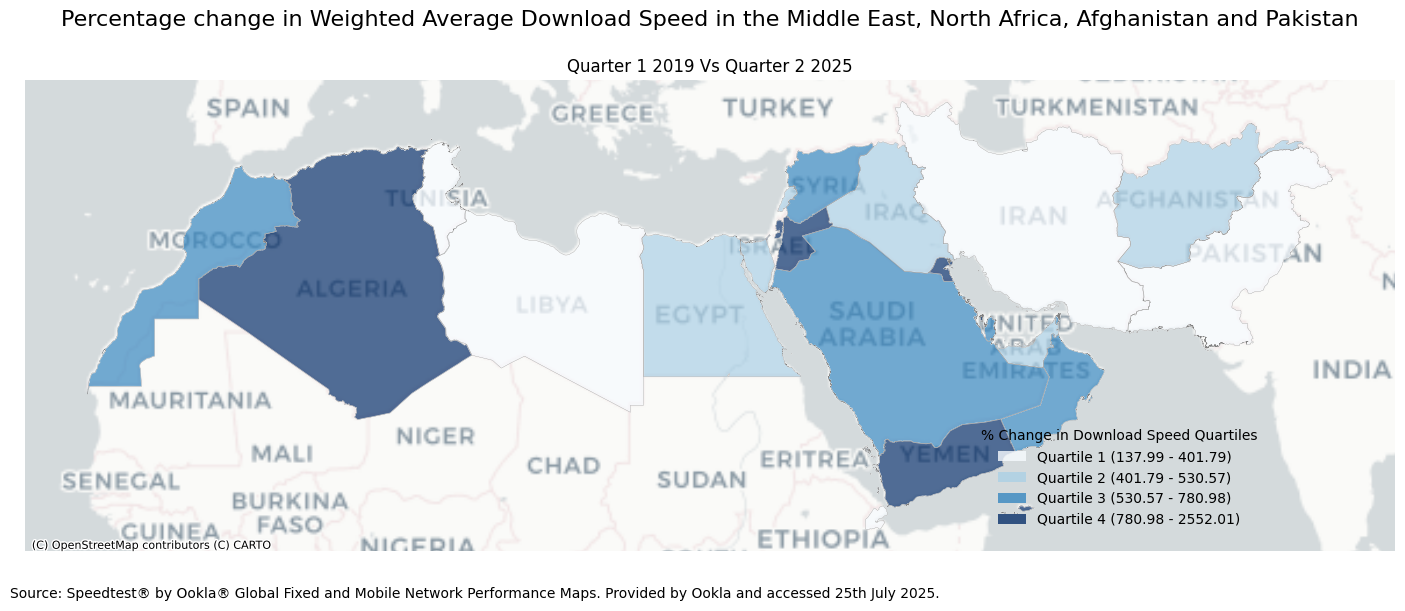

**The fixed broadband internet speed in Algeria has increased by more than 2000% since 2019.** 
Speeds steadily increased since 2019 with a rapid increase after 2023. This could be due to the installation of fiber optic cables, along with Algeria's participation in the Medusa Submarine Cable System<sup>5</sup>. 

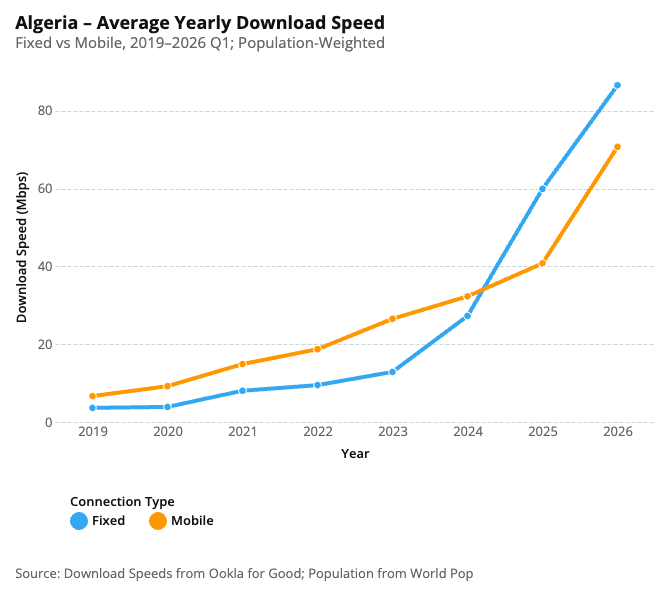

**Algiers, Constantine, Blida have more than 100Mbps internet speeds as of 2026 Q1**. Within this, Constantine city has higher speeds than other areas in the Wilaya, aligning with existing research that urban areas typically enjoy better connectivity. 

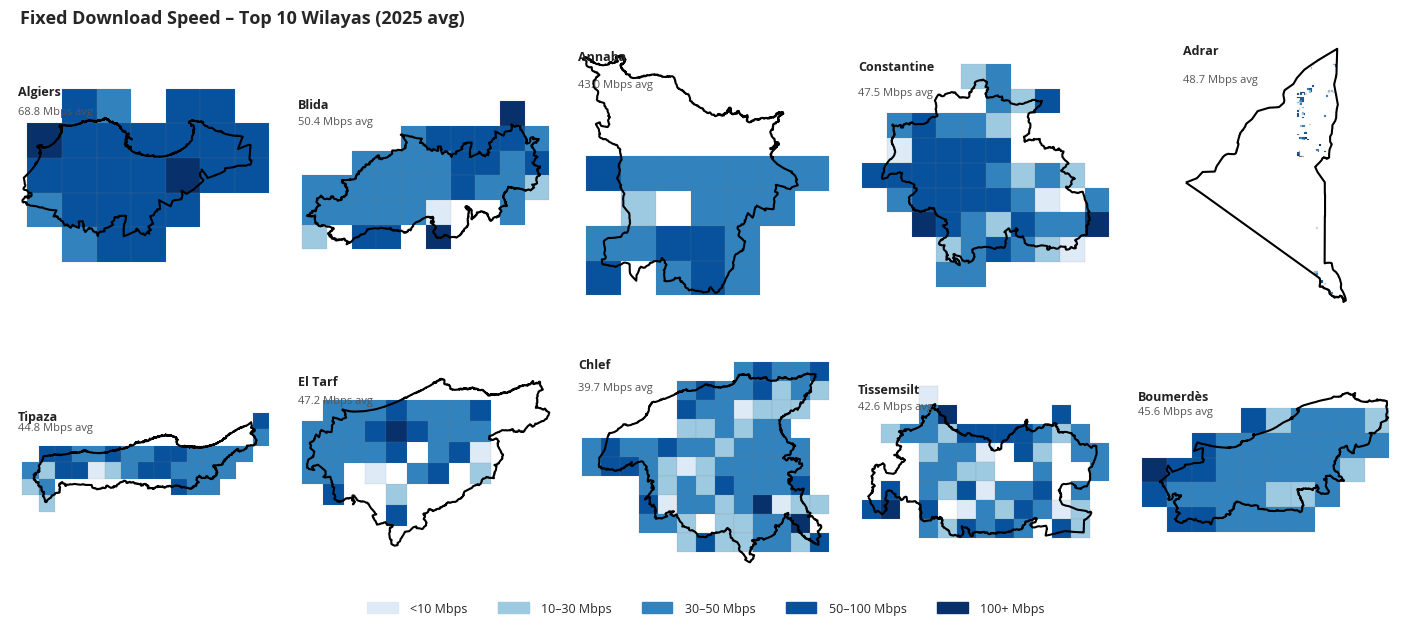


In [79]:

import pandas as pd
from bokeh.io import output_notebook, show
from bokeh.plotting import figure
from bokeh.models import ColumnDataSource, HoverTool
import geopandas as gpd

DATA_DIR = "../../data/processed_data/"
BOUNDARIES_DIR = "../../data/boundaries/"

In [104]:
fixed_pop_weighted = pd.read_csv(str(DATA_DIR) + "algeria_pop_weighted_trends_fixed.csv")
mobile_pop_weighted = pd.read_csv(str(DATA_DIR) + "algeria_pop_weighted_trends_mobile.csv")

fixed = pd.read_csv(str(DATA_DIR) + "algeria_national_trends_fixed.csv")
mobile = pd.read_csv(str(DATA_DIR) + "algeria_national_trends_mobile.csv")

fixed_subnational = pd.read_csv(str(DATA_DIR) + "algeria_subnational_trends_fixed.csv")
mobile_subnational = pd.read_csv(str(DATA_DIR) + "algeria_subnational_trends_fixed.csv")

In [112]:
fixed_pw_adm1 = pd.read_csv(str(DATA_DIR) + "algeria_pop_weighted_adm1_z12_fixed.csv")
mobile_pw_adm1 = pd.read_csv(str(DATA_DIR) + "algeria_pop_weighted_adm1_z12_mobile.csv")

In [106]:
# National trends plot (Fixed vs Mobile) — Altair
import pandas as pd
import altair as alt
import attaviz

attaviz.enable()  # registers and enables the WBG theme

# Prepare data
national_fixed = fixed_pop_weighted.copy()
national_fixed["connection_type"] = "Fixed"

national_mobile = mobile_pop_weighted.copy()
national_mobile["connection_type"] = "Mobile"

national_combined = pd.concat([national_fixed, national_mobile], ignore_index=True)

national_yearly = (
    national_combined
    .groupby(["year", "connection_type"], as_index=False)[["pw_download_mbps", "pw_upload_mbps"]]
    .mean()
    .rename(columns={"pw_download_mbps": "download_mbps", "pw_upload_mbps": "upload_mbps"})
)

# Chart
line = (
    alt.Chart(national_yearly)
    .mark_line(point=True)
    .encode(
        x=alt.X("year:O", title="Year"),
        y=alt.Y("download_mbps:Q", title="Download Speed (Mbps)"),
        color=alt.Color("connection_type:N", title="Connection Type"),
        tooltip=[
            alt.Tooltip("year:O", title="Year"),
            alt.Tooltip("connection_type:N", title="Type"),
            alt.Tooltip("download_mbps:Q", title="Download (Mbps)", format=".2f"),
            alt.Tooltip("upload_mbps:Q", title="Upload (Mbps)", format=".2f"),
        ],
    )
    .properties(
        title=alt.TitleParams(
            text="Algeria – Average Yearly Download Speed",
            subtitle="Fixed vs Mobile, 2019–2026 Q1; Population-Weighted",
        ),
        width=600,
        height=350,
    )
)

attaviz.add_caption(line, "Source: Download Speeds from Ookla for Good; Population from World Pop")


alt.VConcatChart(...)

In [107]:
mobile_z12 = pd.read_csv(str(DATA_DIR) + "algeria_grid_data_long_z12_mobile.csv")
fixed_z12 = pd.read_csv(str(DATA_DIR) + "algeria_grid_data_long_z12_fixed.csv")

In [108]:
from shapely.geometry import box
import math

def quadkey_to_bbox(quadkey):
    """Convert a quadkey to a bounding box (xmin, ymin, xmax, ymax) in EPSG:4326"""
    # Convert quadkey to tile coordinates
    tile_x = 0
    tile_y = 0
    zoom = len(quadkey)
    
    for i in range(zoom):
        bit = zoom - i - 1
        mask = 1 << bit
        digit = int(quadkey[i])
        if digit & 1:
            tile_x |= mask
        if digit & 2:
            tile_y |= mask
    
    # Convert tile coordinates to lat/lon
    n = 2.0 ** zoom
    
    # Top-left corner (xmin, ymax)
    lon_min = tile_x / n * 360.0 - 180.0
    lat_max_rad = math.atan(math.sinh(math.pi * (1 - 2 * tile_y / n)))
    lat_max = math.degrees(lat_max_rad)
    
    # Bottom-right corner (xmax, ymin)
    lon_max = (tile_x + 1) / n * 360.0 - 180.0
    lat_min_rad = math.atan(math.sinh(math.pi * (1 - 2 * (tile_y + 1) / n)))
    lat_min = math.degrees(lat_min_rad)
    
    return lon_min, lat_min, lon_max, lat_max


In [109]:
dza_adm0 = gpd.read_file(str(BOUNDARIES_DIR) + "geoBoundaries-DZA-ADM0.geojson")
dza_adm1 = gpd.read_file(str(BOUNDARIES_DIR) + "geoBoundaries-DZA-ADM1.geojson")
dza_adm2 = gpd.read_file(str(BOUNDARIES_DIR) + "geoBoundaries-DZA-ADM2.geojson")

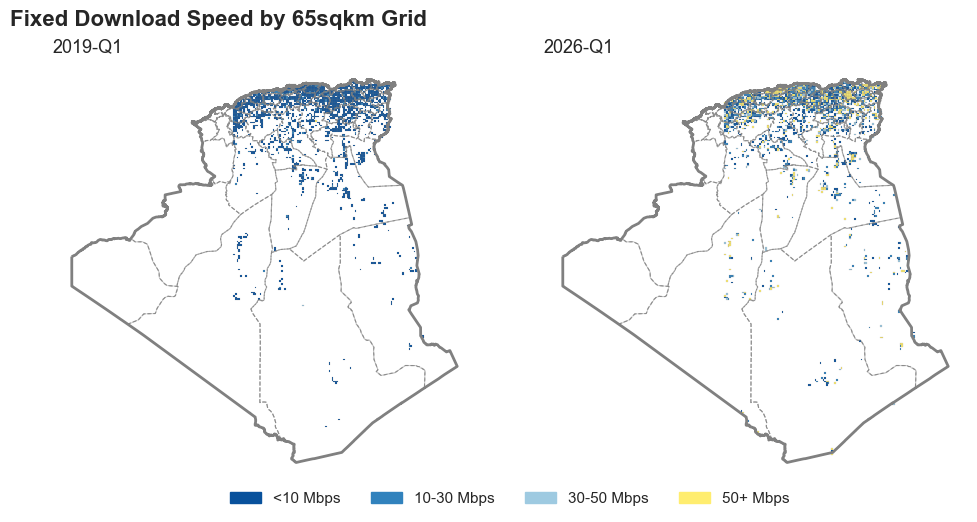

In [195]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from pandas.api.types import CategoricalDtype

df_25 = fixed_z12[fixed_z12['date'] >= '2025-Q1'].copy()
df_25 = df_25.groupby('quadkey_z12', as_index=False).agg({'avg_download_mbps': 'mean'})
df_19 = mobile_z12[(mobile_z12['date'] >= '2019-Q1')&(mobile_z12['date'] <= '2019-Q4')].copy()
df_19 = df_19.groupby('quadkey_z12', as_index=False).agg({'avg_download_mbps': 'mean'})

target_length = 12
df_25['quadkey_z12'] = df_25['quadkey_z12'].astype(str).str.zfill(target_length)
df_19['quadkey_z12'] = df_19['quadkey_z12'].astype(str).str.zfill(target_length)

# Convert quadkeys to bounding boxes
for df in [df_25, df_19]:
    bbox = df['quadkey_z12'].apply(quadkey_to_bbox)
    df['xmin'] = bbox.apply(lambda x: x[0])
    df['ymin'] = bbox.apply(lambda x: x[1])
    df['xmax'] = bbox.apply(lambda x: x[2])
    df['ymax'] = bbox.apply(lambda x: x[3])
    df['geometry'] = df.apply(lambda r: box(r['xmin'], r['ymin'], r['xmax'], r['ymax']), axis=1)

gdf_25 = gpd.GeoDataFrame(df_25, geometry='geometry', crs='EPSG:4326')
gdf_19 = gpd.GeoDataFrame(df_19, geometry='geometry', crs='EPSG:4326')

# Speed buckets
def bucket_speed(x):
    if x < 10:   return '<10 Mbps'
    elif x < 30: return '10-30 Mbps'
    elif x < 50: return '30-50 Mbps'
    else:        return '50+ Mbps'

cat_type = CategoricalDtype(categories=['<10 Mbps', '10-30 Mbps', '30-50 Mbps', '50+ Mbps'], ordered=True)
for gdf in [gdf_25, gdf_19]:
    gdf['speed_bucket'] = gdf['avg_download_mbps'].apply(bucket_speed).astype(cat_type)

# Colormap
colors = ['#08519c', '#3182bd', '#9ecae1', '#ffed6f']
cmap = ListedColormap(colors)

# Plot — no per-axes legend
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Fixed Download Speed by 65sqkm Grid', fontsize=16, weight='bold', x=0.0, ha='left')

for gdf, axis, period in [(gdf_19, ax[0], '2019-Q1'), (gdf_25, ax[1], '2026-Q1')]:
    gdf.plot(ax=axis, column='speed_bucket', legend=False, cmap=cmap,
             linewidth=0.1, edgecolor='gray', categorical=True)
    dza_adm0.boundary.plot(ax=axis, linewidth=2, edgecolor='grey')
    dza_adm1.boundary.plot(ax=axis, linewidth=0.8, edgecolor='grey', linestyle='--', alpha=0.7)
    axis.set_title(period, fontsize=13, loc='left')
    axis.set_axis_off()

# Shared legend — no frame, no title
legend_patches = [
    mpatches.Patch(color=colors[0], label='<10 Mbps'),
    mpatches.Patch(color=colors[1], label='10-30 Mbps'),
    mpatches.Patch(color=colors[2], label='30-50 Mbps'),
    mpatches.Patch(color=colors[3], label='50+ Mbps'),
]
fig.legend(handles=legend_patches,
           loc='lower center', bbox_to_anchor=(0.5, -0.04),
           ncol=4, frameon=False, fontsize=11)

plt.tight_layout()
plt.show()


In [146]:
# ADM1 trends plot (Fixed vs Mobile) — Altair faceted
import altair as alt
import attaviz

attaviz.enable()

# Load both fixed and mobile data
df_fixed = fixed_pw_adm1.copy()
df_mobile = mobile_pw_adm1.copy()

df_fixed["connection_type"] = "Fixed"
df_mobile["connection_type"] = "Mobile"

adm1_combined = pd.concat([df_fixed, df_mobile], ignore_index=True)

yearly = (
    adm1_combined
    .groupby(["adm1_name", "year", "connection_type"], as_index=False)[["pw_download_mbps", "pw_upload_mbps"]]
    .mean()
    .rename(columns={"pw_download_mbps": "download_mbps", "pw_upload_mbps": "upload_mbps"})
)

# Sort wilayas by descending average download speed in 2025
wilaya_order = (
    yearly[yearly["year"] == 2025]
    .groupby("adm1_name")["download_mbps"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

# Faceted chart
facet_chart = (
    alt.Chart(yearly)
    .mark_line(point=True)
    .encode(
        x=alt.X("year:O", title="Year", axis=alt.Axis(labelAngle=45)),
        y=alt.Y("download_mbps:Q", title="Download Speed (Mbps)"),
        color=alt.Color("connection_type:N", title="Connection Type"),
        tooltip=[
            alt.Tooltip("adm1_name:N", title="Wilaya"),
            alt.Tooltip("year:O", title="Year"),
            alt.Tooltip("connection_type:N", title="Type"),
            alt.Tooltip("download_mbps:Q", title="Download (Mbps)", format=".2f"),
        ],
    )
    .properties(width=160, height=120)
    .facet(
        facet=alt.Facet("adm1_name:N", title=None, sort=wilaya_order),
        columns=3,
        title=alt.TitleParams(
            text="Average Yearly Download Speed by Wilaya",
            subtitle="Fixed vs Mobile, 2019–2026; Population Weighted",
        ),
    )
)

attaviz.add_caption(facet_chart, "Source: Download Speeds from Ookla for Good")


alt.VConcatChart(...)

In [ ]:
gdf_fixed_pw = pd.read_csv('../../data/processed_data/algeria_pop_weighted_grid_z12_fixed.csv')
gdf_mobile_pw = pd.read_csv('../../data/processed_data/algeria_pop_weighted_grid_z12_mobile.csv')

target_length = 12
gdf_fixed_pw['quadkey_z12'] = gdf_fixed_pw['quadkey_z12'].astype(str).str.zfill(target_length)
gdf_mobile_pw['quadkey_z12'] = gdf_mobile_pw['quadkey_z12'].astype(str).str.zfill(target_length)

# Convert quadkeys to bounding boxes
for gdf in [gdf_fixed_pw, gdf_mobile_pw]:
    bbox = gdf['quadkey_z12'].apply(quadkey_to_bbox)
    gdf['xmin'] = bbox.apply(lambda x: x[0])
    gdf['ymin'] = bbox.apply(lambda x: x[1])
    gdf['xmax'] = bbox.apply(lambda x: x[2])
    gdf['ymax'] = bbox.apply(lambda x: x[3])
    gdf['geometry'] = gdf.apply(lambda r: box(r['xmin'], r['ymin'], r['xmax'], r['ymax']), axis=1)

gdf_fixed_pw = gpd.GeoDataFrame(gdf_fixed_pw, geometry='geometry', crs='EPSG:4326')
gdf_mobile_pw = gpd.GeoDataFrame(gdf_mobile_pw, geometry='geometry', crs='EPSG:4326')


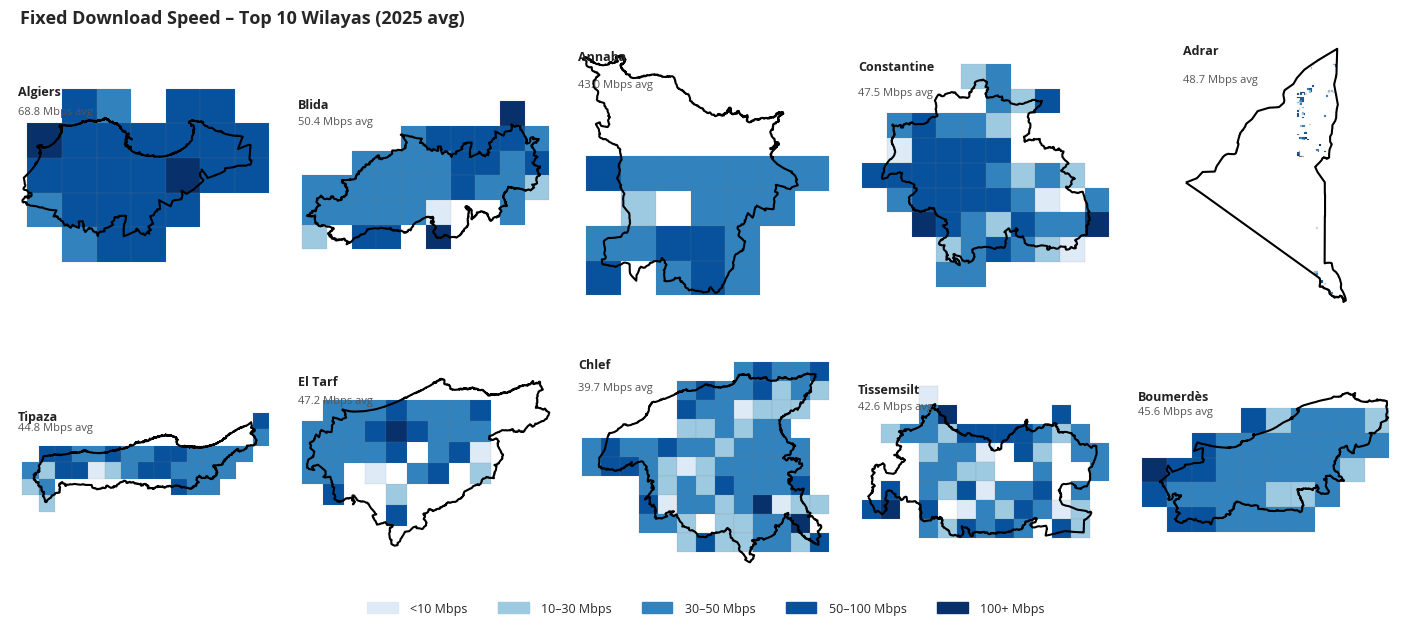

In [193]:
# Top 10 ADM1 regions by fixed download speed (2025 avg)
from matplotlib.colors import ListedColormap
from pandas.api.types import CategoricalDtype
from matplotlib import font_manager

SPEED_LABELS = ['<10 Mbps', '10–30 Mbps', '30–50 Mbps', '50–100 Mbps', '100+ Mbps']
SPEED_COLORS = ['#deebf7', '#9ecae1', '#3182bd', '#08519c', '#08306b']
cat_type = CategoricalDtype(categories=SPEED_LABELS, ordered=True)

_fp_title    = font_manager.FontProperties(family='Open Sans', size=9,  weight='bold')
_fp_speed    = font_manager.FontProperties(family='Open Sans', size=8)
_fp_suptitle = font_manager.FontProperties(family='Open Sans', size=13, weight='bold')
_fp_legend   = font_manager.FontProperties(family='Open Sans', size=9)

def bucket_speed_v2(x):
    if x < 10:    return '<10 Mbps'
    elif x < 30:  return '10–30 Mbps'
    elif x < 50:  return '30–50 Mbps'
    elif x < 100: return '50–100 Mbps'
    else:         return '100+ Mbps'

# Top 10 regions
gdf_with_adm1 = gdf_fixed_pw[gdf_fixed_pw['year'] == 2025].sjoin(
    dza_adm1[['shapeName', 'geometry']], how='left', predicate='intersects'
)
top10_regions = (
    gdf_with_adm1.groupby('shapeName')['avg_download_mbps']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

cmap = ListedColormap(SPEED_COLORS)

fig, axes = plt.subplots(2, 5, figsize=(14, 6), constrained_layout=True)
axes = axes.flatten()

suptitle = fig.suptitle('Fixed Download Speed – Top 10 Wilayas (2025 avg)', ha='left', x=0.01)
suptitle.set_fontproperties(_fp_suptitle)

for ax, region in zip(axes, top10_regions):
    region_boundary = dza_adm1[dza_adm1['shapeName'] == region]
    region_grids = gdf_25.sjoin(
        region_boundary[['shapeName', 'geometry']], how='inner', predicate='intersects'
    ).copy()
    region_grids['speed_bucket'] = region_grids['avg_download_mbps'].apply(bucket_speed_v2).astype(cat_type)

    region_grids.plot(ax=ax, column='speed_bucket', cmap=cmap, legend=False,
                      categorical=True, linewidth=0.1, edgecolor='gray')
    region_boundary.boundary.plot(ax=ax, linewidth=1.5, edgecolor='black')

    mean_speed = region_grids['avg_download_mbps'].mean()

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.text(0.03, 0.97, region, transform=ax.transAxes,
            va='top', ha='left', fontproperties=_fp_title, color='#222222')
    ax.text(0.03, 0.86, f'{mean_speed:.1f} Mbps avg', transform=ax.transAxes,
            va='top', ha='left', fontproperties=_fp_speed, color='#555555')

legend_patches = [
    mpatches.Patch(color=SPEED_COLORS[i], label=SPEED_LABELS[i])
    for i in range(len(SPEED_LABELS))
]
leg = fig.legend(handles=legend_patches,
                 loc='lower center', bbox_to_anchor=(0.5, -0.04),
                 ncol=5, frameon=False)
for text in leg.get_texts():
    text.set_fontproperties(_fp_legend)

plt.show()


## References

1. Stevenson, B. (2006). *The Impact of the Internet on Worker Flows.* Working Paper, The Wharton School, University of Pennsylvania, Philadelphia, PA.
2. Bahia, K., Castells, P., Cruz, G., Masaki, T., Pedros, X., Pfutze, T., Rodriguez-Castelan, C. and H. Winkler (2020). *The Welfare Effects of Mobile Broadband Internet: Evidence from Nigeria.* Policy Research Working Paper No. 9230, World Bank, Washington, DC.
3. Bahia, K., Castells, P., Cruz, G., Masaki, T., Rodriguez-Castelan, C. and V. Sanfelice (2021). *Mobile Broadband Internet, Poverty and Labor Outcomes in Tanzania.* Policy Research Working Paper No. 9749, World Bank, Washington, DC.
4. Ngoa, G. B. N., & Song, J. S. (2021). *Female participation in African labor markets: The role of information and communication technologies.* Telecommunications Policy, 45(9), 102174.
5. Africa Intelligence. (2023, May 16). *EIB negotiates with Algiers to kick-start stalled Medusa submarine cable project.* Africa Intelligence. https://www.africaintelligence.com/north-africa/2023/05/16/eib-negotiates-with-algiers-to-kick-start-stalled-medusa-submarine-cable-project,109975079-bre
